In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('../data/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

(1460, 81)

In [4]:
df.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

In [5]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


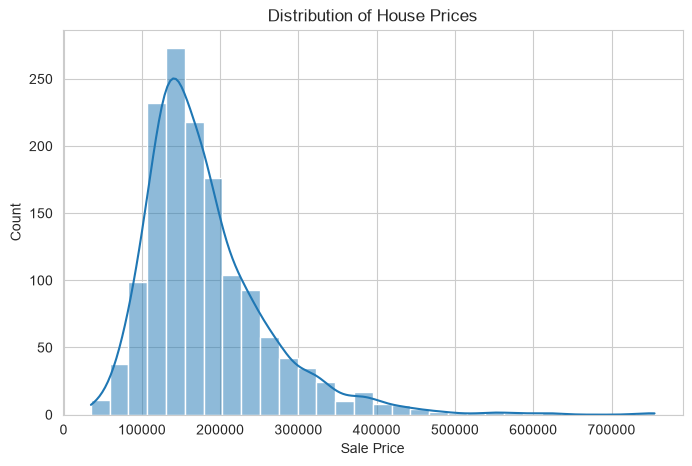

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], bins=30, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Sale Price')
plt.ylabel('Count')
plt.show()

### Observation
The distribution of SalePrice is positively skewed. Most houses are concentrated in the lower-to-mid price range, with a smaller number of expensive properties.

### Selected Features:
GrLivArea (Area): Larger houses usually have higher prices.

OverallQual (Quality): Better construction quality increases value.

BedroomAbvGr (Bedrooms): More rooms generally increase utility.

GarageCars (Garage Capacity): Parking availability often affects price.

Neighborhood: Location is one of the strongest real estate predictors.

YearBuilt / HouseAge: Newer homes tend to be priced higher.

In [7]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill numeric missing values with median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical missing values with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

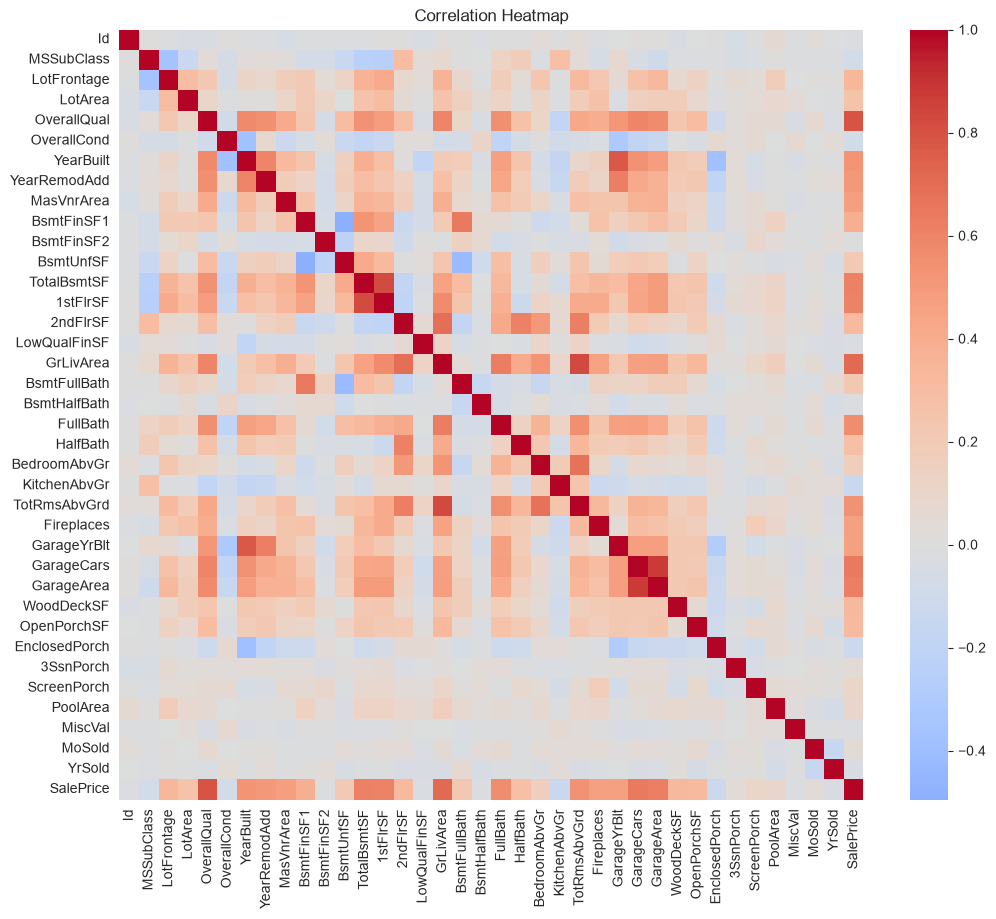

In [8]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [9]:
corr['SalePrice'].sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

### Observation
Features such as OverallQual, GrLivArea, GarageCars, and TotalBsmtSF show strong positive correlation with SalePrice.

In [10]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [11]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(1168, 80) (292, 80)


In [14]:
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

In [15]:
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

R² Score: Indicates the proportion of variance in house prices explained by the model. A value closer to 1.0 means better predictive performance.

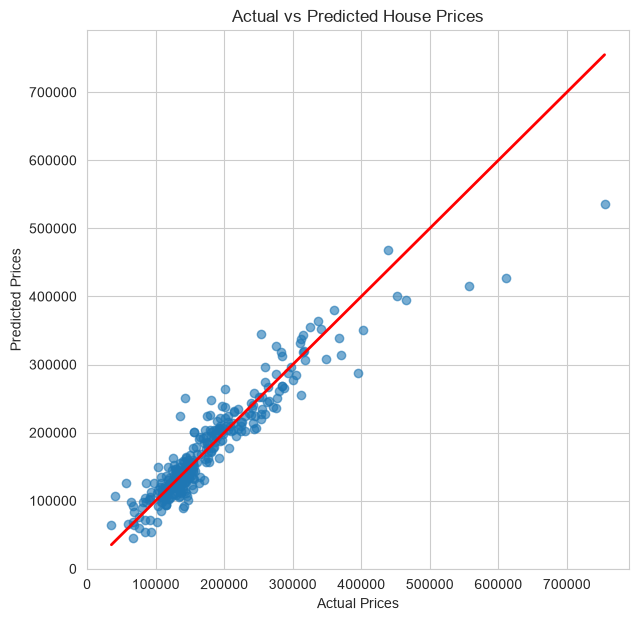

In [16]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.show()

Points closer to the red diagonal line indicate more accurate predictions.

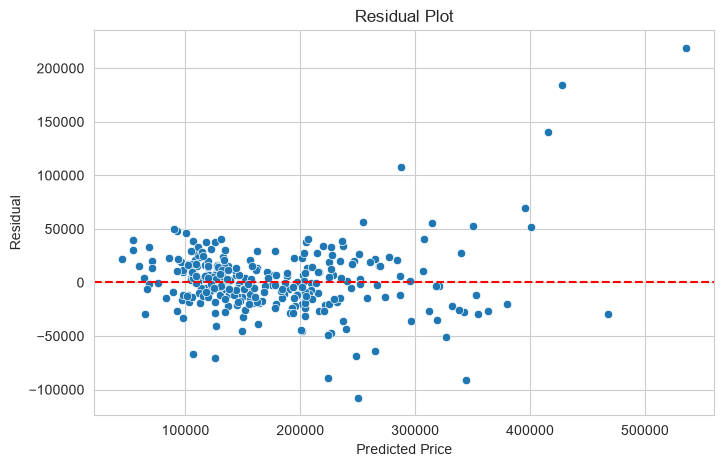

In [17]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.show()

A good linear regression model should show residuals randomly scattered around zero without any visible pattern.

In [18]:
ohe = linear_model.named_steps['preprocessor'].named_transformers_['cat']

encoded_cat_names = ohe.get_feature_names_out(categorical_features)
feature_names = np.concatenate([encoded_cat_names, numeric_features])

coefficients = linear_model.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

coef_df.head(10)

,Feature,Coefficient
42,Neighborhood_NoRidge,41727.904013
49,Neighborhood_StoneBr,38148.156839
43,Neighborhood_NridgHt,24306.682355
98,Exterior1st_BrkFace,22873.166238
223,PoolQC_Ex,22185.015340
117,Exterior2nd_ImStucc,21178.419533
144,BsmtQual_Ex,19940.908424
185,KitchenQual_Ex,19711.113239
14,LandContour_HLS,18753.223747
33,Neighborhood_Crawfor,16875.974139


In [19]:
coef_df.tail(10)

,Feature,Coefficient
39,Neighborhood_NAmes,-13007.593467
41,Neighborhood_NWAmes,-13911.319757
35,Neighborhood_Gilbert,-14543.057556
11,LotShape_IR3,-15182.994851
34,Neighborhood_Edwards,-17280.979154
225,PoolQC_Gd,-19138.033053
13,LandContour_Bnk,-20502.043619
38,Neighborhood_Mitchel,-20844.236534
65,Condition2_PosN,-23855.445569
88,RoofMatl_ClyTile,-28710.125650


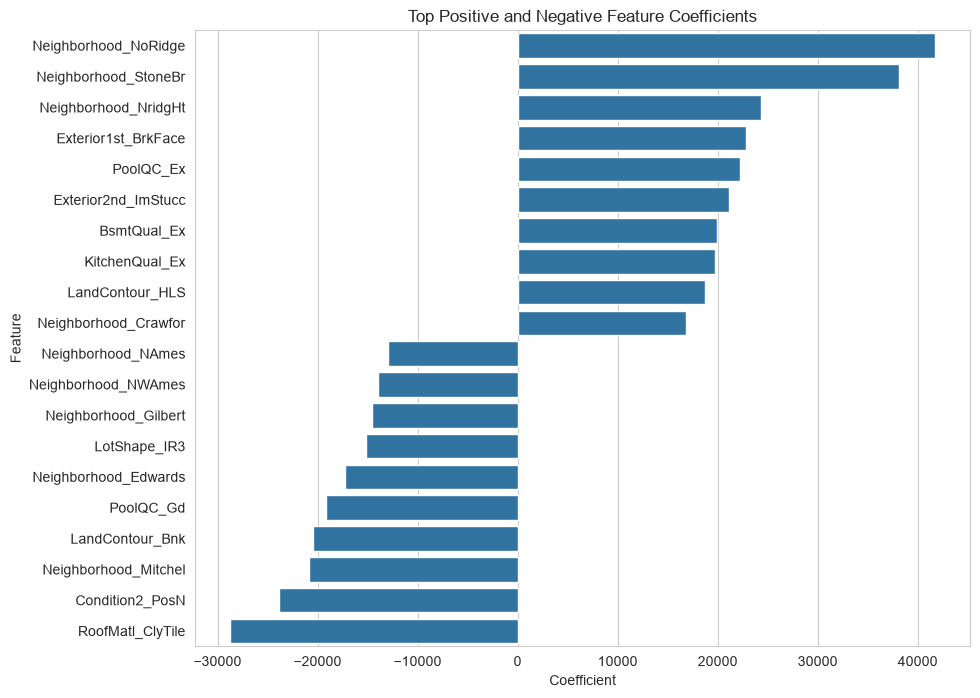

In [20]:
top_features = pd.concat([
    coef_df.head(10),
    coef_df.tail(10)
])

plt.figure(figsize=(10,8))
sns.barplot(data=top_features, x='Coefficient', y='Feature')
plt.title('Top Positive and Negative Feature Coefficients')
plt.show()

Features with large positive coefficients increase predicted price, while large negative coefficients decrease predicted price.

In [21]:
# Predictions from Linear Regression
y_pred = linear_model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Mean Squared Error (MSE):', mse)
print('Root Mean Squared Error (RMSE):', rmse)
print('R² Score:', r2)

Mean Squared Error (MSE): 980422299.1934302
Root Mean Squared Error (RMSE): 31311.695884979308
R² Score: 0.8721798431108744


In [22]:
ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print('Linear Regression RMSE:', rmse)
print('Linear Regression R²:', r2)
print('Ridge Regression RMSE:', ridge_rmse)
print('Ridge Regression R²:', ridge_r2)

Linear Regression RMSE: 31311.695884979308
Linear Regression R²: 0.8721798431108744
Ridge Regression RMSE: 34633.26371793284
Ridge Regression R²: 0.8436229537888517


## Model Comparison

| Model             |     RMSE | R² Score |
| ----------------- | -------: | -------: |
| Linear Regression | 31311.695 |     0.872 |
| Ridge Regression  | 34633.263 |     0.843 |


##Conclusion

Built a complete house price prediction pipeline using Linear Regression.

Performed EDA, missing value treatment, and One-Hot Encoding.

Evaluated the model using MSE, RMSE, and R² score.

Identified important predictors such as Overall Quality, Living Area, Garage Capacity, and Neighborhood.

Compared Linear Regression with Ridge Regression, demonstrating the effect of regularization.